In [ ]:
%pip install -r ./../stellar_classification/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = './star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

display(star.head())


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250


In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


         obj_ID       alpha      delta         u        g         r         i  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573   

          z  run_ID  rerun_ID  ...   spec_obj_ID  class  redshift  plate  \
0  18.79371    3606       301  ...  6.543777e+18      0  0.634794   5812   

     MJD  fiber_ID      u_g      g_r      r_i      i_z  
0  56354       171  1.60352  1.88029  1.22928  0.37202  

[1 rows x 22 columns]
        alpha      delta         u        g         r         i         z  \
0  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573  18.79371   

   class  plate    MJD      u_g      g_r      r_i      i_z  
0      0   5812  56354  1.60352  1.88029  1.22928  0.37202  
Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [4]:
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [5]:
# ============================================================
# Neural Network setup
# ============================================================

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Input size:", input_size)
print("Number of classes:", num_classes)

Input size: 13
Number of classes: 3


In [6]:
# ============================================================
# Import experiment runner
# ============================================================

from stellar_classification.experiments.nn_runner import run_experiments

In [7]:
# ============================================================
# Run Neural Network Experiments
# ============================================================

results_df = run_experiments(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,

    input_size=input_size,
    num_classes=num_classes,

    model_types=[
        "SimpleNN",
        "MediumNN",
        "ComplexNN",
    ],

    learning_rates=[
        0.01,
        0.001,
        0.0001,
    ],

    epochs=1,
)


Training SimpleNN | lr=0.01
Epoch 1/1 | loss=0.4347 | train_acc=83.60% | val_acc=85.38%
✔ Done: SimpleNN | lr=0.01 | loss=0.4347 | train_acc=85.18% | val_acc=85.38% | val_f1=0.8226

Training SimpleNN | lr=0.001
Epoch 1/1 | loss=0.4889 | train_acc=81.85% | val_acc=84.86%
✔ Done: SimpleNN | lr=0.001 | loss=0.4889 | train_acc=84.18% | val_acc=84.86% | val_f1=0.8168

Training SimpleNN | lr=0.0001
Epoch 1/1 | loss=0.7139 | train_acc=71.40% | val_acc=79.76%
✔ Done: SimpleNN | lr=0.0001 | loss=0.7139 | train_acc=77.72% | val_acc=79.76% | val_f1=0.7549

Training MediumNN | lr=0.01
Epoch 1/1 | loss=0.4053 | train_acc=84.28% | val_acc=87.17%
✔ Done: MediumNN | lr=0.01 | loss=0.4053 | train_acc=85.39% | val_acc=87.17% | val_f1=0.8398

Training MediumNN | lr=0.001
Epoch 1/1 | loss=0.4305 | train_acc=83.50% | val_acc=86.45%
✔ Done: MediumNN | lr=0.001 | loss=0.4305 | train_acc=85.95% | val_acc=86.45% | val_f1=0.8351

Training MediumNN | lr=0.0001
Epoch 1/1 | loss=0.6347 | train_acc=75.25% | val_ac

In [8]:
# ============================================================
# Results
# ============================================================

display(results_df)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_f1,val_accuracy,val_f1,test_accuracy,test_f1,history
6,ComplexNN,0.0100,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.424718,83.572430,87.862190,85.997403,0.858866,87.862190,0.844562,88.327765,0.850162,"{'train_loss': [0.42471846348766285], 'train_a..."
3,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.405305,84.277352,87.172044,85.385234,0.853315,87.172044,0.839756,87.462343,0.842421,"{'train_loss': [0.40530473332736705], 'train_a..."
8,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.470718,82.250186,86.805061,85.495507,0.854506,86.805061,0.836785,87.040587,0.839617,"{'train_loss': [0.4707184318617605], 'train_ac..."
4,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.430499,83.501319,86.454511,85.947935,0.859328,86.454511,0.835054,86.668127,0.837035,"{'train_loss': [0.43049889595672025], 'train_a..."
7,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.388499,84.955479,85.862957,86.683774,0.867075,85.862957,0.832848,85.972504,0.833485,"{'train_loss': [0.3884987122254617], 'train_ac..."
0,SimpleNN,0.0100,SimpleNN(\n (net): Sequential(\n (0): Line...,0.434703,83.603347,85.375472,85.176024,0.851218,85.375472,0.822627,85.561702,0.824838,"{'train_loss': [0.4347028445474553], 'train_ac..."
1,SimpleNN,0.0010,SimpleNN(\n (net): Sequential(\n (0): Line...,0.488906,81.850317,84.855124,84.177385,0.841374,84.855124,0.816771,85.035877,0.818107,"{'train_loss': [0.4889059735409272], 'train_ac..."
5,MediumNN,0.0001,MediumNN(\n (net): Sequential(\n (0): Line...,0.634691,75.245280,83.787041,82.224421,0.821012,83.787041,0.803159,83.984225,0.805167,"{'train_loss': [0.6346905327542643], 'train_ac..."
2,SimpleNN,0.0001,SimpleNN(\n (net): Sequential(\n (0): Line...,0.713934,71.400157,79.755710,77.718691,0.773353,79.755710,0.754915,80.089829,0.758827,"{'train_loss': [0.7139337022955196], 'train_ac..."


In [9]:
from stellar_classification.visualization.nn_plots import plot_training_history

In [10]:
best_simple = results_df[results_df["model"] == "SimpleNN"].iloc[0]
best_medium = results_df[results_df["model"] == "MediumNN"].iloc[0]
best_complex = results_df[results_df["model"] == "ComplexNN"].iloc[0]

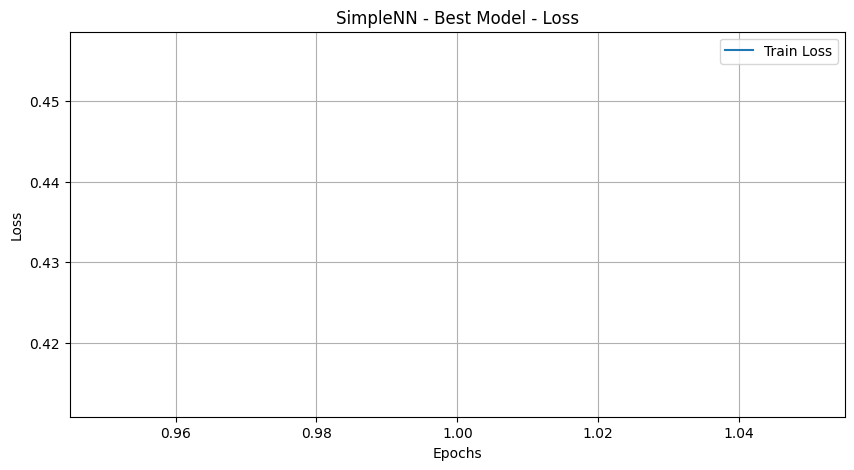

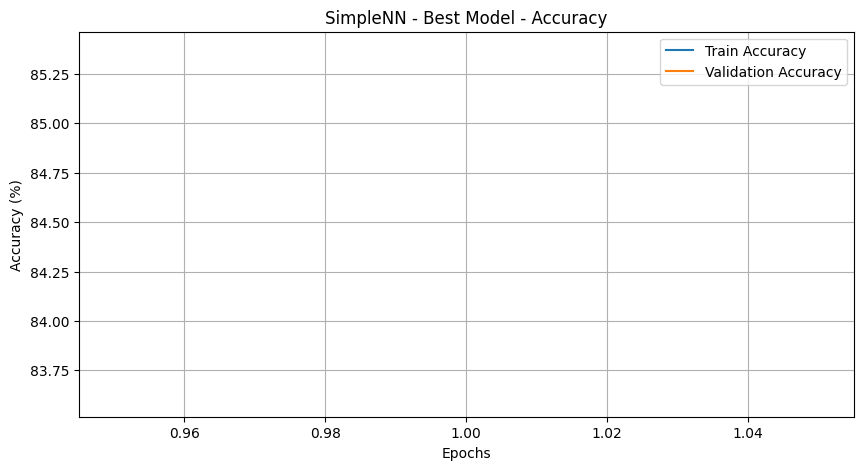

In [11]:
plot_training_history(best_simple["history"], title="SimpleNN - Best Model")

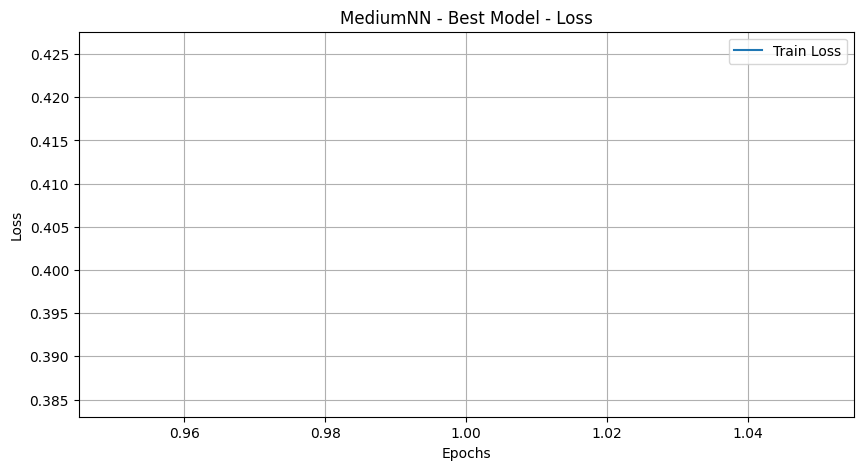

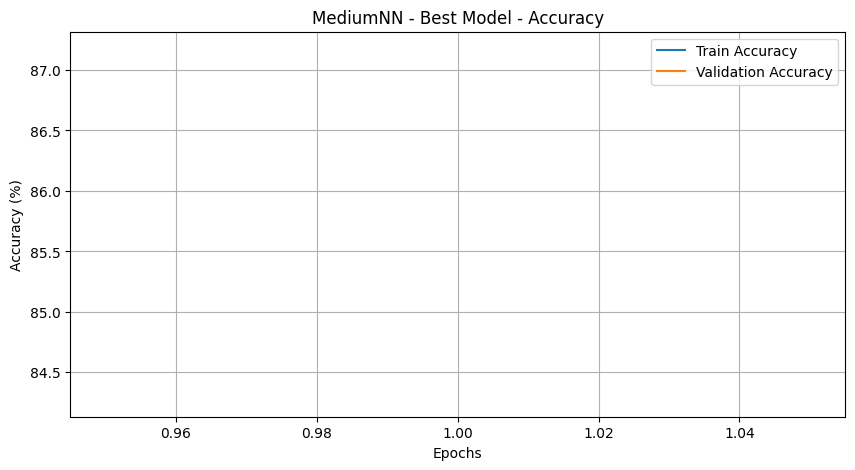

In [12]:
plot_training_history(best_medium["history"], title="MediumNN - Best Model")

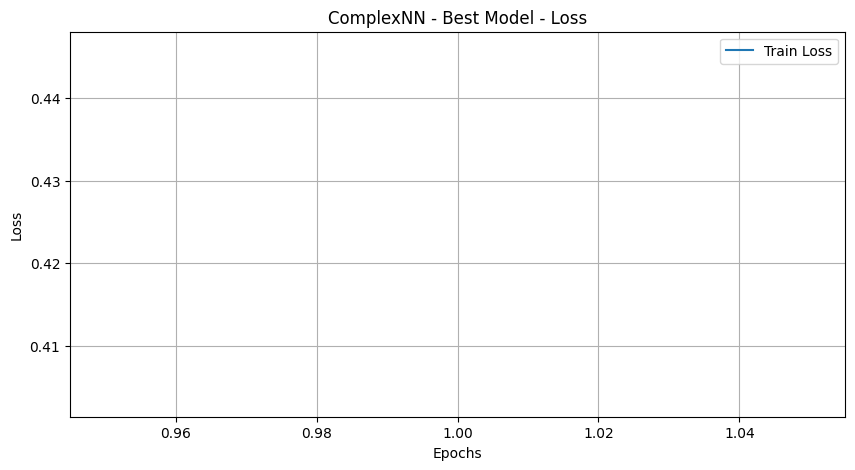

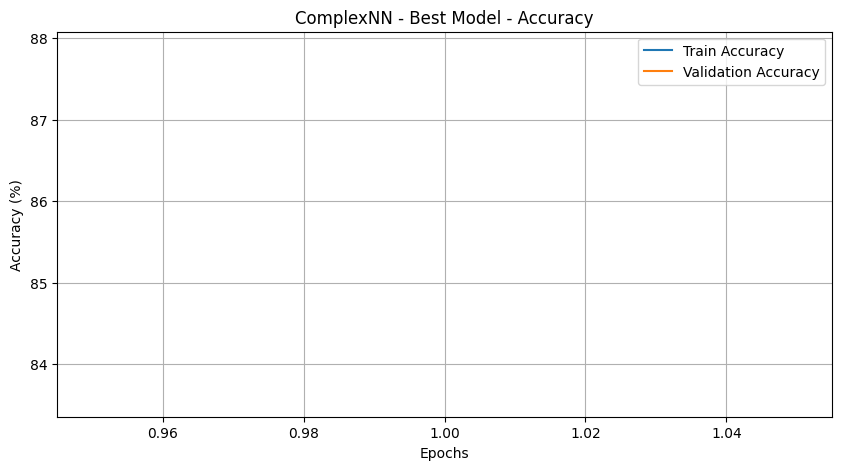

In [13]:
plot_training_history(best_complex["history"], title="ComplexNN - Best Model")

In [14]:
dropout_results = sc.experiments.nn_runner.run_dropout_ablation(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    input_size=input_size,
    num_classes=num_classes,
    results_df=results_df,
    dropout_values=(0.2, 0.3, 0.5),
    epochs=3,
)


Best configuration for MediumNN: lr=0.01 | val_f1=0.8398

Dropout test → MediumNN | lr=0.01 | dropout=0.2
Epoch 1/3 | loss=0.4453 | train_acc=82.81% | val_acc=86.00%
Epoch 2/3 | loss=0.4060 | train_acc=84.46% | val_acc=86.39%
Epoch 3/3 | loss=0.3960 | train_acc=84.86% | val_acc=87.70%
✔ Done: MediumNN | lr=0.01 | dropout=0.2 | val_f1=0.8434

Dropout test → MediumNN | lr=0.01 | dropout=0.3
Epoch 1/3 | loss=0.4671 | train_acc=82.20% | val_acc=86.99%
Epoch 2/3 | loss=0.4297 | train_acc=83.79% | val_acc=86.49%
Epoch 3/3 | loss=0.4280 | train_acc=83.79% | val_acc=87.32%
✔ Done: MediumNN | lr=0.01 | dropout=0.3 | val_f1=0.8337

Dropout test → MediumNN | lr=0.01 | dropout=0.5
Epoch 1/3 | loss=0.5332 | train_acc=79.90% | val_acc=87.18%
Epoch 2/3 | loss=0.4910 | train_acc=81.65% | val_acc=87.70%
Epoch 3/3 | loss=0.4889 | train_acc=81.74% | val_acc=87.54%
✔ Done: MediumNN | lr=0.01 | dropout=0.5 | val_f1=0.8381

Best configuration for ComplexNN: lr=0.01 | val_f1=0.8446

Dropout test → ComplexNN

In [15]:
dropout_results.sort_values(by="val_f1", ascending=False).head(10)

,model,learning_rate,dropout,trained_model,final_loss,final_train_acc,final_val_acc,val_accuracy,val_f1,test_accuracy,test_f1,history
0,MediumNN,0.01,0.2,MediumNN(\n (net): Sequential(\n (0): Line...,0.395993,84.857573,87.703347,87.703347,0.843357,87.900531,0.846653,"{'train_loss': [0.44526371338215015, 0.4060100..."
2,MediumNN,0.01,0.5,MediumNN(\n (net): Sequential(\n (0): Line...,0.488919,81.739014,87.539026,87.539026,0.838099,87.719779,0.840973,"{'train_loss': [0.5332463195666562, 0.49102346..."
3,ComplexNN,0.01,0.2,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.499365,82.530505,87.106315,87.106315,0.835058,87.204908,0.835465,"{'train_loss': [0.5072535949862939, 0.48542211..."
1,MediumNN,0.01,0.3,MediumNN(\n (net): Sequential(\n (0): Line...,0.427967,83.794006,87.319932,87.319932,0.833710,87.621186,0.837778,"{'train_loss': [0.4671144944836061, 0.42966319..."
4,ComplexNN,0.01,0.3,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.550841,80.126144,86.470943,86.470943,0.826641,86.739333,0.830145,"{'train_loss': [0.5499401103530813, 0.55246316..."
5,ComplexNN,0.01,0.5,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.814859,70.100585,70.263461,70.263461,0.673559,70.690694,0.679170,"{'train_loss': [0.7219321109310294, 0.79638165..."


In [16]:
best_medium_dropout = dropout_results[dropout_results["model"] == "MediumNN"].iloc[0]
best_complex_dropout = dropout_results[dropout_results["model"] == "ComplexNN"].iloc[0]

ValueError: x and y must have same first dimension, but have shapes (1,) and (3,)

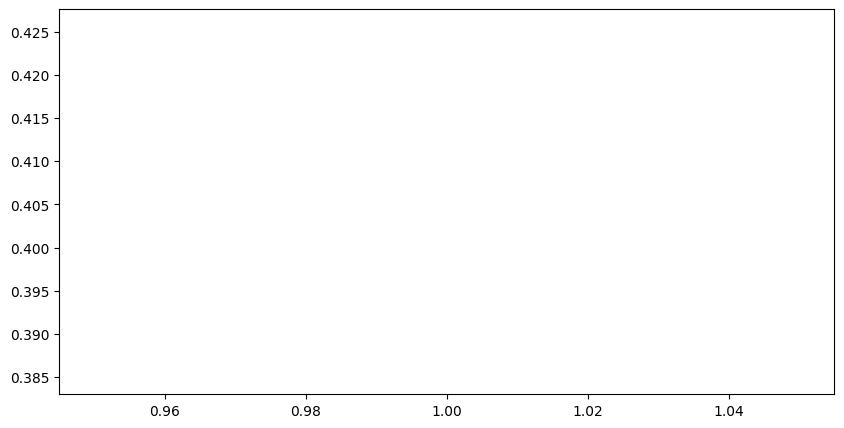

In [17]:
from stellar_classification.visualization.nn_plots import plot_dropout_comparison

plot_dropout_comparison(
    best_medium["history"],
    best_medium_dropout["history"],
    title="MediumNN Comparison"
)

plot_dropout_comparison(
    best_complex["history"],
    best_complex_dropout["history"],
    title="ComplexNN Comparison"
)

In [18]:
from stellar_classification.visualization.model_selection import get_final_candidates

final_sorted = get_final_candidates(
    results_df=results_df,
    dropout_results=dropout_results,
    top_k=3
)

display(final_sorted)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_f1,val_accuracy,val_f1,test_accuracy,test_f1,history,dropout
0,ComplexNN,0.0100,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.424718,83.572430,87.862190,85.997403,0.858866,87.862190,0.844562,88.327765,0.850162,"{'train_loss': [0.42471846348766285], 'train_a...",NaN
3,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.395993,84.857573,87.703347,NaN,NaN,87.703347,0.843357,87.900531,0.846653,"{'train_loss': [0.44526371338215015, 0.4060100...",0.2
1,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.405305,84.277352,87.172044,85.385234,0.853315,87.172044,0.839756,87.462343,0.842421,"{'train_loss': [0.40530473332736705], 'train_a...",NaN
4,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.488919,81.739014,87.539026,NaN,NaN,87.539026,0.838099,87.719779,0.840973,"{'train_loss': [0.5332463195666562, 0.49102346...",0.5
2,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.470718,82.250186,86.805061,85.495507,0.854506,86.805061,0.836785,87.040587,0.839617,"{'train_loss': [0.4707184318617605], 'train_ac...",NaN
5,ComplexNN,0.0100,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.499365,82.530505,87.106315,NaN,NaN,87.106315,0.835058,87.204908,0.835465,"{'train_loss': [0.5072535949862939, 0.48542211...",0.2



ComplexNN:
  Accuracy  : 88.33%
  Precision: 0.8532
  Recall   : 0.8520
  F1       : 0.8502
  Confusion Matrix:
[[10094   405   282]
 [  266  3088   194]
 [  432   552  2944]]


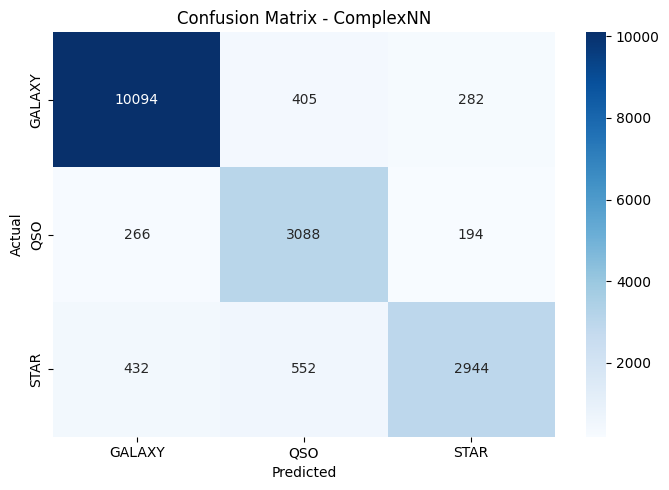

In [19]:
from stellar_classification.experiments.nn_runner import device
from stellar_classification.inference.predictor import evaluate_neural

# Miglior modello assoluto
best_model_row = final_sorted.iloc[0]

best_metrics = evaluate_neural(
    test_loader=test_loader,
    model=best_model_row["trained_model"],
    device=device,
    model_name=f"{best_model_row['model']}"
)

# Stampa metriche
sc.print_metrics(best_metrics)

# Confusion matrix

class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    class_names=class_names,
    title=f"Confusion Matrix - {best_model_row['model']}"
)

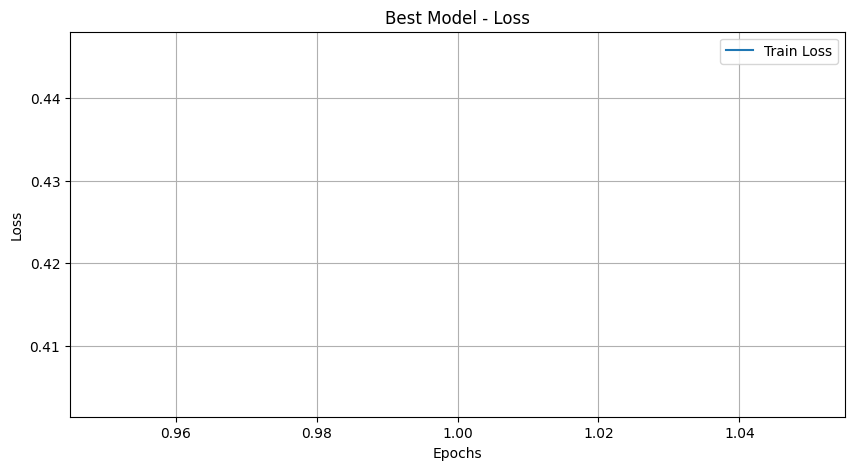

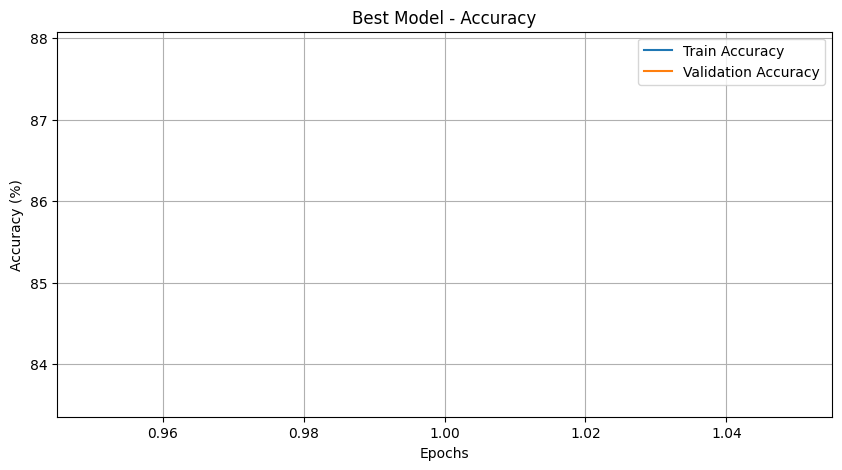

In [20]:
plot_training_history(best_model_row["history"], title="Best Model")

1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257


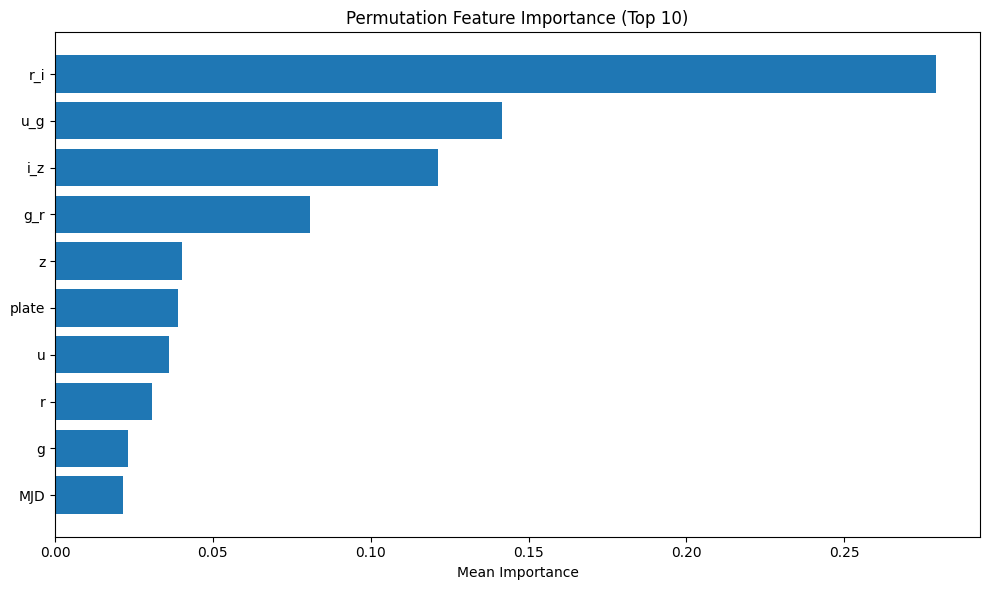

In [21]:
from stellar_classification.utils.wrapper import TorchModelWrapper

from stellar_classification.inference.predictor import compute_permutation_importance


wrapped_model = TorchModelWrapper(best_model_row["trained_model"], device)

imp = compute_permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    feature_names=feature_names,
    n_jobs=1
)

sc.plot_permutation_importance(imp, top_n=10)

In [22]:
from stellar_classification.experiments.feature_ablation import run_feature_ablation

best_model_row = final_sorted.iloc[0]

importance_scores = imp

ablation_results = run_feature_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    feature_names=feature_names,
    best_model_row=best_model_row,
    input_size=X_train.shape[1],
    num_classes=num_classes,
    device=device,
    importance_scores=importance_scores,
    epochs=2
)

ablation_results


Best model: ComplexNN | lr=0.01 | dropout=0.0

Training with top-1 features: ['r_i']
Epoch 1/2 | loss=0.8242 | train_acc=59.85% | val_acc=68.79%
Epoch 2/2 | loss=0.8092 | train_acc=61.62% | val_acc=72.29%

Training with top-2 features: ['r_i', 'u_g']
Epoch 1/2 | loss=0.5552 | train_acc=78.93% | val_acc=79.77%
Epoch 2/2 | loss=0.5315 | train_acc=79.84% | val_acc=81.50%

Training with top-3 features: ['r_i', 'u_g', 'i_z']
Epoch 1/2 | loss=0.5006 | train_acc=81.06% | val_acc=82.25%
Epoch 2/2 | loss=0.4696 | train_acc=82.03% | val_acc=82.63%

Training with top-4 features: ['r_i', 'u_g', 'i_z', 'g_r']
Epoch 1/2 | loss=0.4527 | train_acc=82.83% | val_acc=84.79%
Epoch 2/2 | loss=0.4115 | train_acc=84.23% | val_acc=84.73%

Training with top-5 features: ['r_i', 'u_g', 'i_z', 'g_r', 'z']
Epoch 1/2 | loss=0.4106 | train_acc=84.36% | val_acc=88.07%
Epoch 2/2 | loss=0.3672 | train_acc=85.70% | val_acc=87.95%

Training with top-6 features: ['r_i', 'u_g', 'i_z', 'g_r', 'z', 'plate']
Epoch 1/2 | loss

,n_features,features,val_f1,test_f1
0,1,[r_i],0.623671,0.626988
1,2,"[r_i, u_g]",0.773865,0.782172
2,3,"[r_i, u_g, i_z]",0.790633,0.797536
3,4,"[r_i, u_g, i_z, g_r]",0.818960,0.825455
4,5,"[r_i, u_g, i_z, g_r, z]",0.849479,0.851950
5,6,"[r_i, u_g, i_z, g_r, z, plate]",0.851818,0.856978
6,7,"[r_i, u_g, i_z, g_r, z, plate, u]",0.855296,0.861650
7,8,"[r_i, u_g, i_z, g_r, z, plate, u, r]",0.833823,0.842586
8,9,"[r_i, u_g, i_z, g_r, z, plate, u, r, g]",0.843034,0.845199
9,10,"[r_i, u_g, i_z, g_r, z, plate, u, r, g, MJD]",0.854597,0.859038


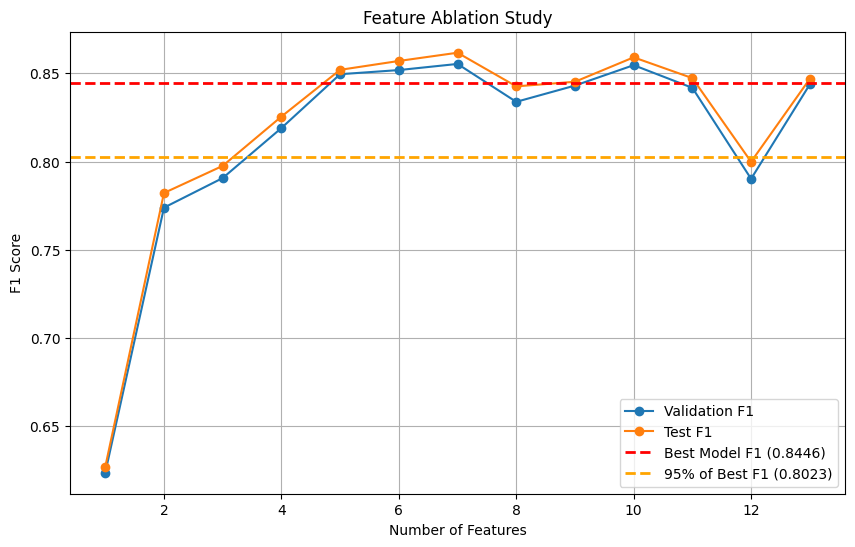

In [23]:
from stellar_classification.visualization.model_selection import plot_feature_ablation

best_val_f1 = final_sorted.iloc[0]["val_f1"]

plot_feature_ablation(
    ablation_results,
    best_val_f1=best_val_f1
)

In [24]:
from stellar_classification.experiments.feature_ablation import (
    get_feature_subset_threshold
)

best_subset = get_feature_subset_threshold(
    ablation_results,
    best_val_f1=best_model_row["val_f1"],
    threshold=0.95,
)

if best_subset is not None:
    print("\n===== 95% FEATURE SUBSET =====")
    print(f"Target F1       : {0.95 * best_model_row['val_f1']:.4f}")
    print(f"Reached F1      : {best_subset['val_f1']:.4f}")
    print(f"N. features     : {best_subset['n_features']}")
    print("\nSelected features:")
    for f in best_subset["features"]:
        print(f" - {f}")
else:
    print("No subset reached the required threshold.")


===== 95% FEATURE SUBSET =====
Target F1       : 0.8023
Reached F1      : 0.8190
N. features     : 4

Selected features:
 - r_i
 - u_g
 - i_z
 - g_r


In [25]:
print(
    f"Relative performance: "
    f"{100 * best_subset['val_f1'] / best_model_row['val_f1']:.2f}%"
)

Relative performance: 96.97%


# PCA